In [11]:
import pandas as pd
import utils as uti

In [12]:
df = pd.read_pickle("../data/train_df.pkl")

In [13]:
import pickle
from pathlib import Path

file_path = Path("../data/models.pkl")

if file_path.exists():
    print('loading model file')
    with file_path.open("rb") as file:
        models = pickle.load(file)
else:
    print('creating new model file')
    models = {}

loading model file


# param optimization

In [14]:
walds = pd.read_pickle("../data/walds.pkl")
walds.head()

,var,wald,corr,corr ind
0,V14,1951.546659,-0.099085,False
1,V4,1703.435651,-0.106422,False
2,V10,1617.13706,-0.102396,False
3,V3,1541.035483,-0.420856,True
4,V2,1478.19184,-0.530143,True


In [15]:
X = df[walds['var'].tolist()]
y = df.Class

In [16]:
import numpy as np
import optuna
import xgboost as xgb

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score


def objective(trial):
    params = {
        "objective": "binary:logistic",
        "eval_metric": "aucpr",
        "tree_method": "hist",

        # "n_estimators": trial.suggest_int(
        #     "n_estimators", 200, 2000
        # ),

        # Large upper limit; early stopping determines the useful number
        "n_estimators": 5000,
        
        "max_depth": trial.suggest_int(
            "max_depth", 2, 10
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.005, 0.2, log=True
        ),
        "min_child_weight": trial.suggest_float(
            "min_child_weight", 1, 20, log=True
        ),
        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),
        "gamma": trial.suggest_float(
            "gamma", 0, 10
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha", 1e-8, 10, log=True
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda", 1e-8, 10, log=True
        ),

        "random_state": 42,
        "n_jobs": -1,
        
        "early_stopping_rounds": 100,
    }

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    fold_pr_aucs = []

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y)):
        X_train = X.iloc[train_idx]
        X_valid = X.iloc[valid_idx]
        y_train = y.iloc[train_idx]
        y_valid = y.iloc[valid_idx]

        model = xgb.XGBClassifier(**params)

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_valid, y_valid)],
            verbose=False
        )

        predictions = model.predict_proba(X_valid)[:, 1]

        # Average precision is commonly used as the PR-AUC summary metric
        pr_auc = average_precision_score(
            y_valid,
            predictions
        )

        fold_pr_aucs.append(pr_auc)

        # Report the mean PR-AUC achieved so far
        trial.report(
            np.mean(fold_pr_aucs),
            step=fold
        )

        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_pr_aucs)

In [17]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=10,
        n_warmup_steps=2
    )
)

study.optimize(
    objective,
    n_trials=25,
    show_progress_bar=True
)

print("Best AUC:", study.best_value)
print("Best parameters:")
print(study.best_params)

[I 2026-09-08 22:20:55,904] A new study created in memory with name: no-name-f85c769a-4eec-4da1-9cb6-61754bce3481


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-09-08 22:21:08,262] Trial 0 finished with value: 0.8492201679619118 and parameters: {'max_depth': 5, 'learning_rate': 0.1667521176194013, 'min_child_weight': 8.960785365368121, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'gamma': 1.5599452033620265, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469893}. Best is trial 0 with value: 0.8492201679619118.
[I 2026-09-08 22:21:16,162] Trial 1 finished with value: 0.8148366210189293 and parameters: {'max_depth': 7, 'learning_rate': 0.06813099824138592, 'min_child_weight': 1.0636066512540283, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9329770563201687, 'gamma': 2.1233911067827616, 'reg_alpha': 4.329370014459266e-07, 'reg_lambda': 4.4734294104626844e-07}. Best is trial 0 with value: 0.8492201679619118.
[I 2026-09-08 22:21:35,612] Trial 2 finished with value: 0.8554468590290188 and parameters: {'max_depth': 4, 'learning_rate': 0.034646653174710614, 'min_child_weight': 3.64731628491

## optimization summary

In [18]:
import matplotlib.pyplot as plt

In [19]:
from optuna.importance import get_param_importances

importance_dict = get_param_importances(study)

/tmp/ipykernel_1187939/3694072603.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_optimization_history(study)


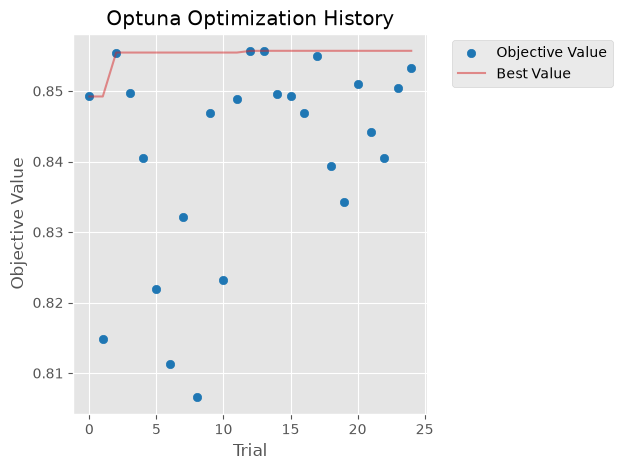

In [20]:
fig = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title("Optuna Optimization History")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1187939/2144959284.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_param_importances(study)


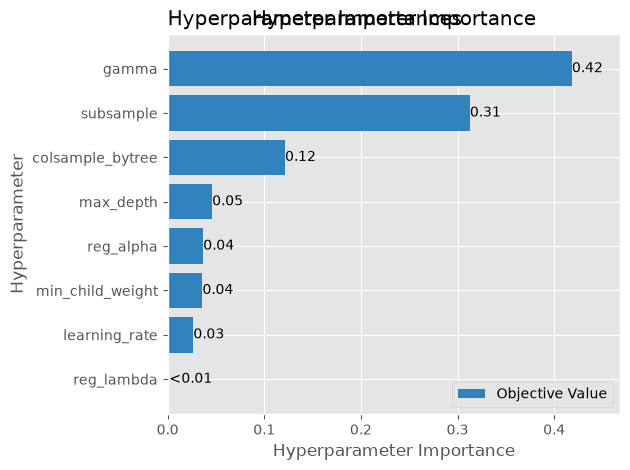

In [21]:
fig = optuna.visualization.matplotlib.plot_param_importances(study)
plt.title("Hyperparameter Importance")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1187939/1725605251.py:1: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_slice(
/tmp/ipykernel_1187939/1725605251.py:5: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


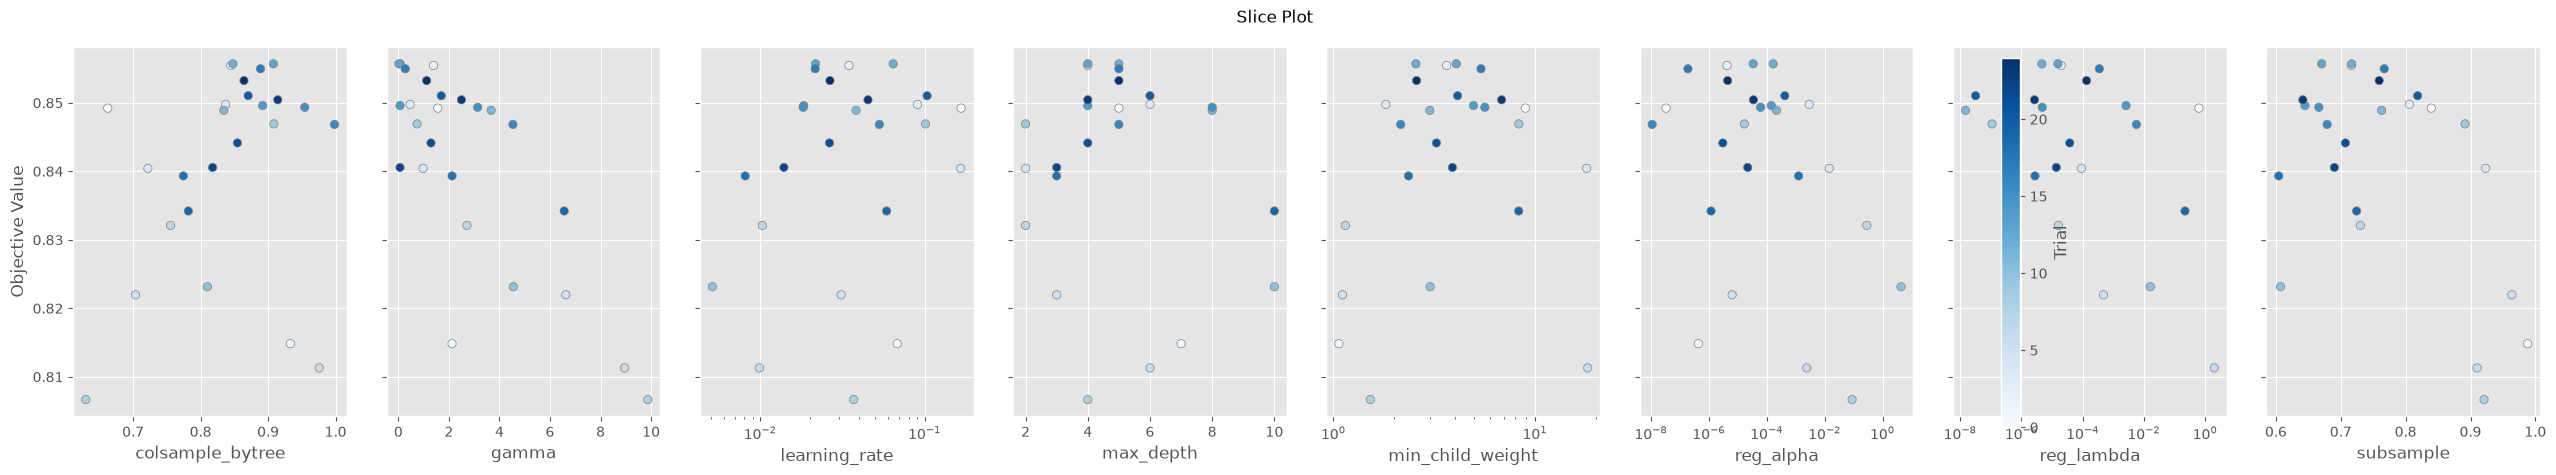

In [22]:
fig = optuna.visualization.matplotlib.plot_slice(
    study,
    params=list(importance_dict.keys())
)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1187939/1484866845.py:1: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_parallel_coordinate(


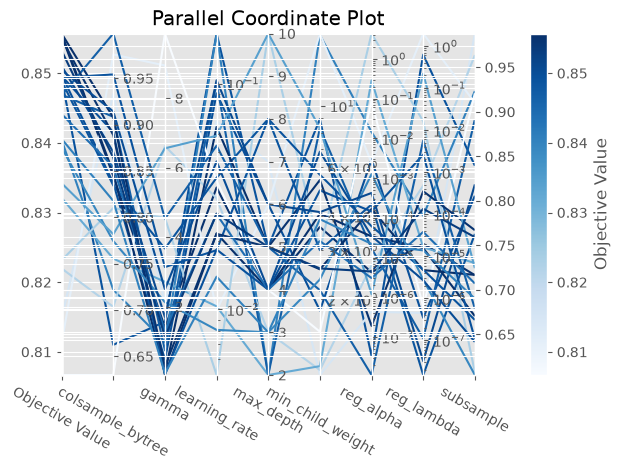

In [23]:
fig = optuna.visualization.matplotlib.plot_parallel_coordinate(
    study,
    params=list(importance_dict.keys())
)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1187939/2829545407.py:1: ExperimentalWarning: optuna.visualization.matplotlib._contour.plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_contour(


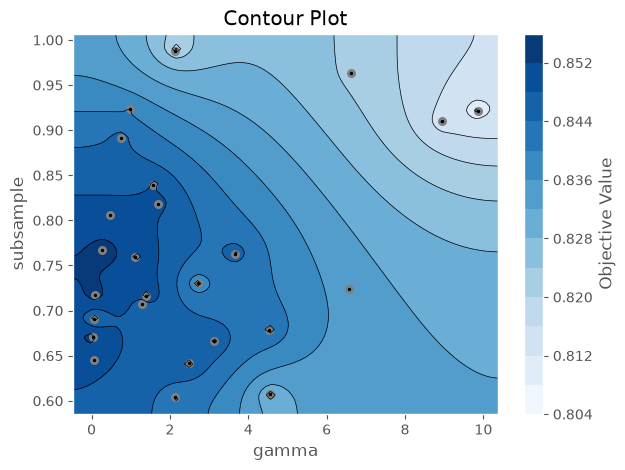

In [24]:
fig = optuna.visualization.matplotlib.plot_contour(
    study,
    params=list(importance_dict.keys())[:2]
)
plt.tight_layout()
plt.show()

In [25]:
trials_df = study.trials_dataframe()

best_trials = (
    trials_df
    .query("state == 'COMPLETE'")
    .sort_values("value", ascending=False)
    .head(10)
)

In [26]:
best_trials

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,params_reg_alpha,params_reg_lambda,params_subsample,state
13,13,0.855693,2026-09-08 22:24:46.403554,2026-09-08 22:25:19.366290,0 days 00:00:32.962736,0.907774,0.025655,0.021710,4,4.070882,3.399718e-05,1.562772e-05,0.670509,COMPLETE
12,12,0.855683,2026-09-08 22:24:33.672467,2026-09-08 22:24:46.402161,0 days 00:00:12.729694,0.847885,0.077577,0.064365,5,2.564719,1.666566e-04,4.676307e-06,0.716859,COMPLETE
2,2,0.855447,2026-09-08 22:21:16.163990,2026-09-08 22:21:35.612490,0 days 00:00:19.448500,0.844741,1.394939,0.034647,4,3.647316,4.258943e-06,1.982698e-05,0.716492,COMPLETE
17,17,0.854969,2026-09-08 22:26:25.154647,2026-09-08 22:26:52.447471,0 days 00:00:27.292824,0.888778,0.272190,0.021590,5,5.393195,1.900072e-07,3.511883e-04,0.767028,COMPLETE
24,24,0.853243,2026-09-08 22:29:12.393985,2026-09-08 22:29:28.350525,0 days 00:00:15.956540,0.864235,1.119613,0.026559,5,2.583522,4.458432e-06,1.343596e-04,0.759182,COMPLETE
20,20,0.851032,2026-09-08 22:27:55.413306,2026-09-08 22:28:02.939939,0 days 00:00:07.526633,0.870444,1.696781,0.103543,6,4.129184,4.216289e-04,3.197226e-08,0.818484,COMPLETE
23,23,0.850437,2026-09-08 22:28:55.621151,2026-09-08 22:29:12.392895,0 days 00:00:16.771744,0.914302,2.495082,0.045239,4,6.829036,3.476166e-05,2.679739e-06,0.641537,COMPLETE
3,3,0.849769,2026-09-08 22:21:35.614328,2026-09-08 22:21:48.090847,0 days 00:00:12.476519,0.836966,0.464504,0.090546,6,1.818786,2.936998e-03,3.425446e-07,0.805694,COMPLETE
14,14,0.849597,2026-09-08 22:25:19.367958,2026-09-08 22:25:44.602022,0 days 00:00:25.234064,0.891934,0.066162,0.018398,4,4.947053,1.442224e-04,2.617495e-03,0.644790,COMPLETE
15,15,0.849346,2026-09-08 22:25:44.603475,2026-09-08 22:26:14.443670,0 days 00:00:29.840195,0.954257,3.136760,0.018277,8,5.634647,6.137994e-05,4.792402e-06,0.666223,COMPLETE


# fit best model

In [27]:
best_params = {
    **study.best_params,
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": -1,
}

final_model = xgb.XGBClassifier(**best_params)

final_model.fit(X, y, verbose=False)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9077744952992656
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


# partial dependence plots

In [28]:
# import matplotlib.pyplot as plt
# from sklearn.inspection import PartialDependenceDisplay

# features = walds["var"].tolist()

# display = PartialDependenceDisplay.from_estimator(
#     final_model,
#     X,
#     features=features,
#     n_cols=3
# )

# n_rows = (len(features) + 2) // 3

# display.figure_.set_size_inches(
#     18,
#     5 * n_rows
# )

# display.figure_.tight_layout()

# plt.show()

# save models

In [29]:
models['xgb'] = final_model

In [30]:
with open("../data/models.pkl", "wb") as file:
    pickle.dump(models, file)